In [70]:
import joblib
import numpy as np
import pandas as pd
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
from sklearn.metrics import f1_score
from scipy.stats import entropy

warnings.filterwarnings('ignore')

X_train_raw   = np.load('../models/ds2/X_train.npy')
X_test_raw    = np.load('../models/ds2/X_test.npy')
y_test        = np.load('../models/ds2/y_test.npy')
feature_names = pd.read_csv('../models/ds2/feature_names.csv').squeeze().tolist()

X_train = pd.DataFrame(X_train_raw, columns=feature_names)
X_test  = pd.DataFrame(X_test_raw,  columns=feature_names)

class_names = ['Healthy', 'Benign', 'Cancer']
n_features  = len(feature_names)
train_means = X_train.mean()   #used for feature masking in correctness

rf_model  = joblib.load('../models/ds2/ds2_random_forest.pkl')
svm_model = joblib.load('../models/ds2/ds2_svm.pkl')
mlp_model = joblib.load('../models/ds2/ds2_mlp.pkl')

models = {
    'Random Forest': rf_model,
    'SVM':           svm_model,
    'MLP':           mlp_model,
}

os.makedirs('../plots/ds2/evaluation', exist_ok=True)

print(f"Test set size : {X_test.shape[0]} samples")
print(f"Features      : {n_features}")
print(f"Classes       : {dict(zip(*np.unique(y_test, return_counts=True)))}")


Test set size : 120 samples
Features      : 16
Classes       : {1: 51, 2: 43, 3: 26}


In [4]:
#shap values for all models
#RF: TreeExplainer 
rf_explainer   = shap.TreeExplainer(rf_model)
shap_rf        = rf_explainer.shap_values(X_test)   #list of 3 arrays (n_test, n_feat)

#SVM and MLP: KernelExplainer (model-agnostic)
background = shap.sample(X_train, 100, random_state=42)

svm_explainer  = shap.KernelExplainer(svm_model.predict_proba, background)
shap_svm       = svm_explainer.shap_values(X_test)

mlp_explainer  = shap.KernelExplainer(mlp_model.predict_proba, background)
shap_mlp       = mlp_explainer.shap_values(X_test)

shap_values_all = {
    'Random Forest': shap_rf,
    'SVM':           shap_svm,
    'MLP':           shap_mlp,
}
print("SHAP values computed for all models.")

  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

SHAP values computed for all models.


---
## Metric 1 — Correctness: Incremental Deletion

Features are removed one-by-one in **descending order of global SHAP importance** (or LIME importance).  
Removed features are replaced with their training-set mean.  
A good XAI method should produce the **steepest F1 drop** compared to random-order deletion.

**AOPC** (Area Over the Perturbation Curve) summarises this: higher AOPC = better correctness.


In [7]:
# ── Global SHAP importance = mean |SHAP| averaged over classes ───────────────
def global_shap_importance(shap_vals):
    """shap_vals: list of (n_test, n_feat) arrays, one per class."""
    mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
    return np.argsort(mean_abs)[::-1]   # descending

# ── Global LIME importance ────────────────────────────────────────────────────
def global_lime_importance(model_fn, n_runs=30):
    """Average |weight| across a sample of test instances and all classes."""
    lime_exp = lime.lime_tabular.LimeTabularExplainer(
        X_train.values, feature_names=feature_names,
        class_names=class_names, mode='classification', random_state=42)
    importances = np.zeros(n_features)
    indices = np.random.RandomState(0).choice(len(X_test), min(n_runs, len(X_test)), replace=False)
    for idx in indices:
        for cls_idx in range(len(class_names)):
            exp = lime_exp.explain_instance(
                X_test.iloc[idx].values, model_fn,
                num_features=n_features, labels=[cls_idx])
            for feat_idx, weight in exp.local_exp.get(cls_idx, []):
                importances[feat_idx] += abs(weight)
    return np.argsort(importances)[::-1]

# ── Incremental deletion ─────────────────────────────────────────────────────
def incremental_deletion_f1(model, X, y, feature_order):
    """Return F1 (macro) at each step of removing top-k features."""
    X_masked = X.copy()
    f1_scores = [f1_score(y, model.predict(X_masked), average='macro')]
    for feat_idx in feature_order:
        X_masked = X_masked.copy()
        X_masked.iloc[:, feat_idx] = train_means.iloc[feat_idx]
        f1_scores.append(f1_score(y, model.predict(X_masked), average='macro'))
    return np.array(f1_scores)

def aopc(f1_curve):
    """Area Over Perturbation Curve = mean drop from baseline."""
    return float(np.mean(f1_curve[0] - f1_curve))

print("Correctness helpers defined.")

Correctness helpers defined.


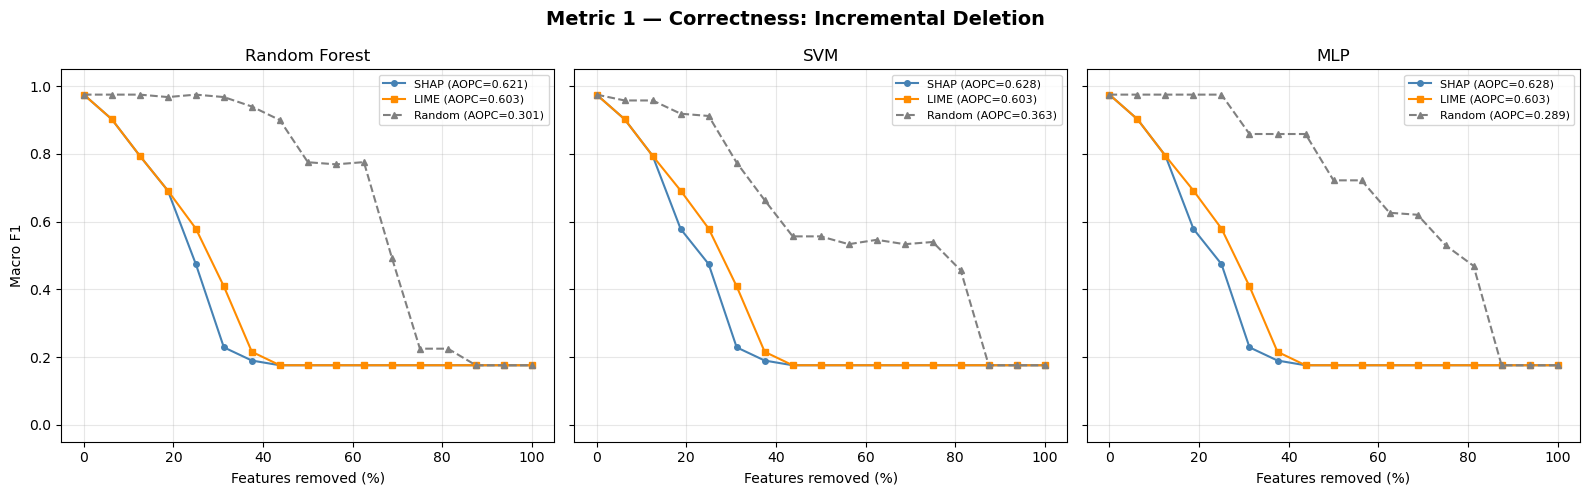

Correctness plots saved.


In [11]:
np.random.seed(42)
correctness_results = {}

x_axis = np.linspace(0, 100, n_features + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('Metric 1 — Correctness: Incremental Deletion', fontsize=14, fontweight='bold')

for ax, (model_name, model) in zip(axes, models.items()):
    shap_vals = shap_values_all[model_name]

    order_shap   = global_shap_importance(shap_vals)
    order_lime   = global_lime_importance(model.predict_proba)
    order_random = np.random.permutation(n_features)

    f1_shap   = incremental_deletion_f1(model, X_test, y_test, order_shap)
    f1_lime   = incremental_deletion_f1(model, X_test, y_test, order_lime)
    f1_random = incremental_deletion_f1(model, X_test, y_test, order_random)

    correctness_results[model_name] = {
        'aopc_shap'  : aopc(f1_shap),
        'aopc_lime'  : aopc(f1_lime),
        'aopc_random': aopc(f1_random),
        'f1_shap'    : f1_shap,
        'f1_lime'    : f1_lime,
        'f1_random'  : f1_random,
    }

    ax.plot(x_axis, f1_shap,   marker='o', ms=4, label=f'SHAP (AOPC={aopc(f1_shap):.3f})',   color='steelblue')
    ax.plot(x_axis, f1_lime,   marker='s', ms=4, label=f'LIME (AOPC={aopc(f1_lime):.3f})',   color='darkorange')
    ax.plot(x_axis, f1_random, marker='^', ms=4, label=f'Random (AOPC={aopc(f1_random):.3f})', color='grey', linestyle='--')
    ax.set_title(model_name)
    ax.set_xlabel('Features removed (%)')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Macro F1')
plt.tight_layout()
plt.savefig('../plots/ds2/evaluation/correctness_incremental_deletion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correctness plots saved.")

---
## Metric 2 — Consistency

**2a. SHAP Consistency** — TreeExplainer (RF) is exact and deterministic, yielding perfect consistency by definition. For KernelExplainer (SVM, MLP), we run 3 times with different background seeds and measure the stability of the top-5 feature set using Jaccard similarity.

**2b. LIME Consistency** — LIME is stochastic by nature. We run 5 times on each of 10 test instances and measure how stable the top-5 feature set is across runs using Jaccard similarity.


Random Forest: TreeExplainer is deterministic → Reiteration Similarity = 1.0 (exact)


  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

SVM: Reiteration mean = 1.0000,  min = 1.0000


  0%|          | 0/120 [00:00<?, ?it/s]

  0%|          | 0/120 [00:00<?, ?it/s]

MLP: Reiteration mean = 1.0000,  min = 1.0000
SHAP consistency computed.
Random Forest: Reiteration mean = 0.7117,  min = 0.3333
SVM: Reiteration mean = 0.6750,  min = 0.3333
MLP: Reiteration mean = 0.7450,  min = 0.2667
LIME consistency computed.


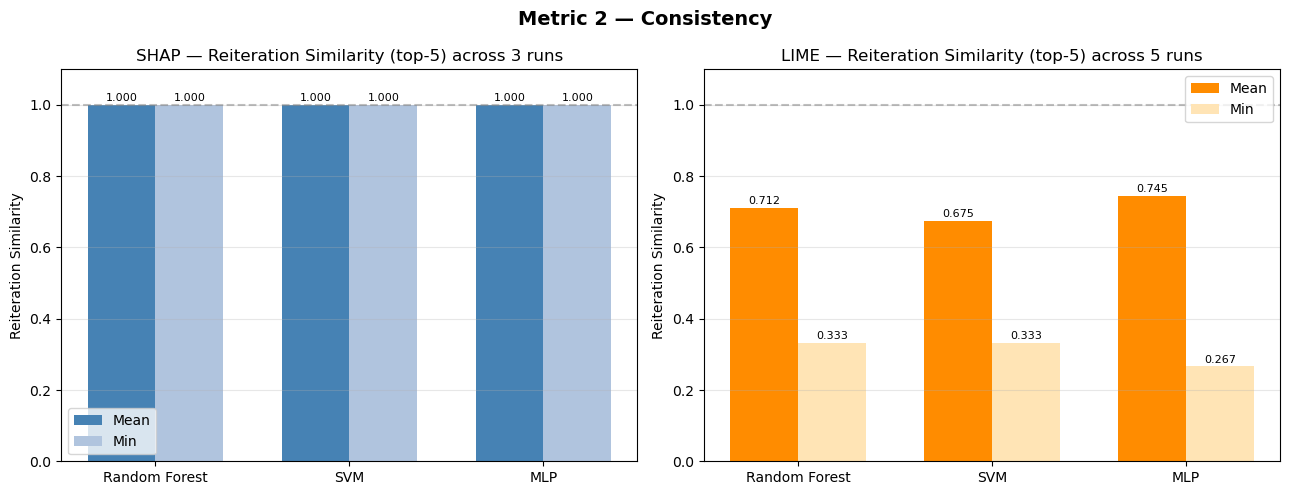

In [29]:
# ── Shared similarity metric ──────────────────────────────────────────────
def reiteration_similarity(list_a, list_b):
    """
    Position-aware similarity between two ordered feature lists.
    Counts exact matches at the same position (index-sensitive).
    Unlike Jaccard, order and duplicates matter.
    """
    assert len(list_a) == len(list_b), "Lists must be the same length"
    matches = sum(a == b for a, b in zip(list_a, list_b))
    return matches / len(list_a)


def top_k_features(shap_vals, k):
    """Return ordered list of top-k feature indices by mean absolute SHAP value."""
    imp = np.mean([np.abs(s).mean(axis=0) for s in shap_vals], axis=0)
    return list(np.argsort(imp)[::-1][:k])  # ordered list, not a set


# ── SHAP consistency (Reiteration Similarity on top-k feature lists) ──────
TOP_K      = 5
N_RUNS_SHAP = 3

for model_name, model in models.items():
    topk0 = top_k_features(shap_values_all[model_name], k=TOP_K)

    if model_name == 'Random Forest':
        consistency_results[model_name] = {
            'shap_reiteration_mean': 1.0,
            'shap_reiteration_min':  1.0,
        }
        print(f"{model_name}: TreeExplainer is deterministic → Reiteration Similarity = 1.0 (exact)")
    else:
        bg     = shap.sample(X_train, 100, random_state=42)  # fixed background
        scores = []
        for run in range(1, N_RUNS_SHAP):
            sv       = shap.KernelExplainer(model.predict_proba, bg).shap_values(X_test)
            topk_run = top_k_features(sv, k=TOP_K)
            scores.append(reiteration_similarity(topk0, topk_run))

        consistency_results[model_name] = {
            'shap_reiteration_mean': float(np.mean(scores)),
            'shap_reiteration_min':  float(np.min(scores)),
        }
        print(f"{model_name}: Reiteration mean = {np.mean(scores):.4f},  min = {np.min(scores):.4f}")

print("SHAP consistency computed.")


# ── LIME consistency (Reiteration Similarity on top-k feature lists) ──────
N_RUNS_LIME = 5
LIME_SAMPLE = 10

lime_base = lime.lime_tabular.LimeTabularExplainer(
    X_train.values, feature_names=feature_names,
    class_names=class_names, mode='classification')

sample_indices = np.random.RandomState(0).choice(len(X_test), LIME_SAMPLE, replace=False)

for model_name, model in models.items():
    all_scores = []
    for idx in sample_indices:
        run_topk = []
        for run in range(N_RUNS_LIME):
            exp = lime_base.explain_instance(
                X_test.iloc[idx].values, model.predict_proba,
                num_features=n_features,
                labels=list(range(len(class_names)))
            )
            # aggregate top-k features across classes as ordered list
            top_feats = []
            for cls_idx in range(len(class_names)):
                ranked = sorted(exp.local_exp.get(cls_idx, []), key=lambda x: -abs(x[1]))
                top_feats.extend(f for f, _ in ranked[:TOP_K])
            run_topk.append(top_feats)

        # reiteration similarity: each run vs run 0
        all_scores.extend(
            reiteration_similarity(run_topk[0], run_topk[r])
            for r in range(1, N_RUNS_LIME)
        )

    consistency_results[model_name]['lime_reiteration_mean'] = float(np.mean(all_scores))
    consistency_results[model_name]['lime_reiteration_min']  = float(np.min(all_scores))
    print(f"{model_name}: Reiteration mean = {np.mean(all_scores):.4f},  min = {np.min(all_scores):.4f}")

print("LIME consistency computed.")


# ── Plot: Consistency comparison ──────────────────────────────────────────
model_labels = list(models.keys())
shap_means   = [consistency_results[m]['shap_reiteration_mean'] for m in model_labels]
shap_mins    = [consistency_results[m]['shap_reiteration_min']  for m in model_labels]
lime_means   = [consistency_results[m]['lime_reiteration_mean'] for m in model_labels]
lime_mins    = [consistency_results[m]['lime_reiteration_min']  for m in model_labels]

x     = np.arange(len(model_labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Metric 2 — Consistency', fontsize=14, fontweight='bold')

# ── SHAP ──────────────────────────────────────────────────────────────────
bars1 = ax1.bar(x - width/2, shap_means, width, label='Mean', color='steelblue')
bars2 = ax1.bar(x + width/2, shap_mins,  width, label='Min',  color='lightsteelblue')
ax1.set_title(f'SHAP — Reiteration Similarity (top-{TOP_K}) across {N_RUNS_SHAP} runs')
ax1.set_xticks(x); ax1.set_xticklabels(model_labels)
ax1.set_ylim(0, 1.1); ax1.set_ylabel('Reiteration Similarity')
ax1.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar in bars1: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars2: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

# ── LIME ──────────────────────────────────────────────────────────────────
bars3 = ax2.bar(x - width/2, lime_means, width, label='Mean', color='darkorange')
bars4 = ax2.bar(x + width/2, lime_mins,  width, label='Min',  color='moccasin')
ax2.set_title(f'LIME — Reiteration Similarity (top-{TOP_K}) across {N_RUNS_LIME} runs')
ax2.set_xticks(x); ax2.set_xticklabels(model_labels)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Reiteration Similarity')
ax2.axhline(1.0, color='grey', linestyle='--', alpha=0.5)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
for bar in bars3: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)
for bar in bars4: ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/ds2/evaluation/consistency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Metric 3 — Contrastivity: KL Divergence between class SHAP distributions

For each feature, we compare the SHAP value distributions between class pairs.  
**High KL divergence** means the model uses that feature differently across classes — a sign of good discriminative explanations.  
We report the **mean KL divergence across all features** per class pair, for each model.

In [74]:
def kl_divergence_shap(shap_a, shap_b, n_bins=30):
    """Symmetric KL divergence between SHAP distributions of two classes (per feature)."""
    all_vals = np.concatenate([shap_a, shap_b])
    lo, hi   = all_vals.min() - 1e-9, all_vals.max() + 1e-9
    bins     = np.linspace(lo, hi, n_bins + 1)
    p, _ = np.histogram(shap_a, bins=bins, density=True)
    q, _ = np.histogram(shap_b, bins=bins, density=True)
    p = p + 1e-10;  q = q + 1e-10   # Laplace smoothing
    p /= p.sum();   q /= q.sum()
    return float(0.5 * (entropy(p, q) + entropy(q, p)))   # symmetric KL

pairs       = [(0, 1, 'Healthy vs Benign'),
               (0, 2, 'Healthy vs Cancer'),
               (1, 2, 'Benign vs Cancer')]

contrastivity_results = {}

for model_name in models:
    shap_vals = shap_values_all[model_name]
    pair_kl   = {}
    for cls_a, cls_b, label in pairs:
        kl_per_feat = [
            kl_divergence_shap(shap_vals[cls_a][:, f], shap_vals[cls_b][:, f])
            for f in range(n_features)
        ]
        pair_kl[label] = {
            'mean': float(np.mean(kl_per_feat)),
            'per_feature': kl_per_feat,
        }
    contrastivity_results[model_name] = pair_kl

print("KL divergence computed for all models.")

KL divergence computed for all models.


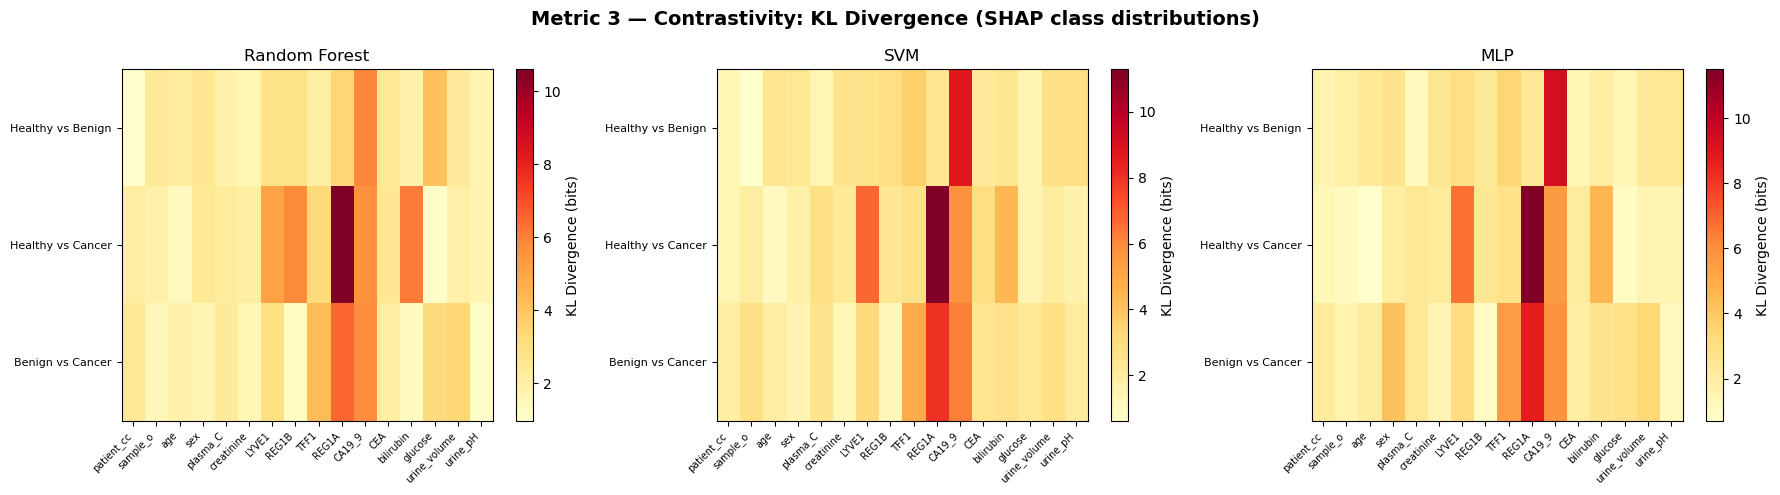

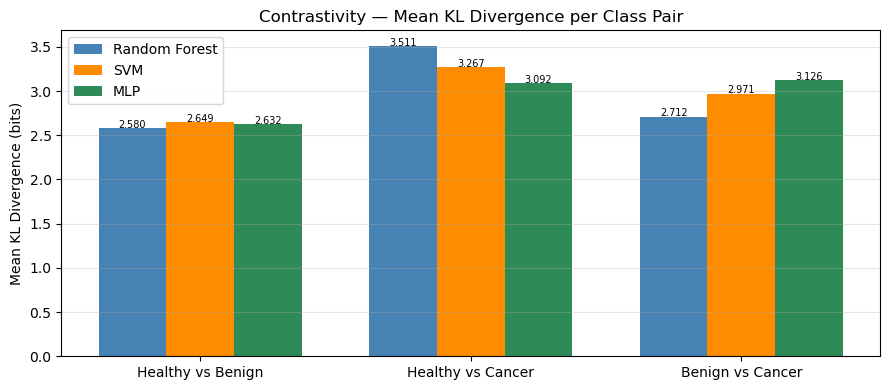

In [76]:
# ── Heatmap: KL divergence per model (features × class pairs) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Metric 3 — Contrastivity: KL Divergence (SHAP class distributions)', fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, models):
    kl_matrix = np.array([
        contrastivity_results[model_name][label]['per_feature']
        for _, _, label in pairs
    ])   # shape (3, n_features)

    im = ax.imshow(kl_matrix, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(n_features))
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(3))
    ax.set_yticklabels([label for _, _, label in pairs], fontsize=8)
    ax.set_title(model_name)
    plt.colorbar(im, ax=ax, label='KL Divergence (bits)')

plt.tight_layout()
plt.savefig('../plots/ds2/evaluation/contrastivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Bar chart: mean KL per model ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(pairs))
width = 0.25
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (model_name, color) in enumerate(zip(models, colors)):
    means = [contrastivity_results[model_name][label]['mean'] for _, _, label in pairs]
    bars  = ax.bar(x + i * width, means, width, label=model_name, color=color)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)

ax.set_xticks(x + width); ax.set_xticklabels([label for _, _, label in pairs])
ax.set_ylabel('Mean KL Divergence (bits)')
ax.set_title('Contrastivity — Mean KL Divergence per Class Pair')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/ds2/evaluation/contrastivity_bar.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Summary — All Models, All Metrics

Consolidated table and comparison chart across RF, SVM, and MLP.


In [79]:
rows = []
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_results[model_name]

    rows.append({
        'Model'                       : model_name,
        # Correctness
        'AOPC SHAP'                   : round(cr['aopc_shap'],   4),
        'AOPC LIME'                   : round(cr['aopc_lime'],   4),
        'AOPC Random (baseline)'      : round(cr['aopc_random'], 4),
        # Consistency
        'SHAP Reiteration (mean)'      : round(co['shap_reiteration_mean'], 4),
        'SHAP Reiteration (min)'       : round(co['shap_reiteration_min'],  4),
        'LIME Reiteration (mean)'         : round(co['lime_reiteration_mean'],  4),
        'LIME Reiteration (min)'          : round(co['lime_reiteration_min'],   4),
        # Contrastivity
        'KL Healthy vs Benign (mean)' : round(ct['Healthy vs Benign']['mean'], 4),
        'KL Healthy vs Cancer (mean)' : round(ct['Healthy vs Cancer']['mean'], 4),
        'KL Benign vs Cancer (mean)'  : round(ct['Benign vs Cancer']['mean'],  4),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
print(summary_df.to_string())
summary_df.to_csv('../plots/ds1/evaluation/summary_table.csv')
print("\nSummary saved to ../plots/ds2/evaluation/summary_table.csv")


               AOPC SHAP  AOPC LIME  AOPC Random (baseline)  SHAP Reiteration (mean)  SHAP Reiteration (min)  LIME Reiteration (mean)  LIME Reiteration (min)  KL Healthy vs Benign (mean)  KL Healthy vs Cancer (mean)  KL Benign vs Cancer (mean)
Model                                                                                                                                                                                                                                              
Random Forest     0.6214     0.6031                  0.3007                      1.0                     1.0                   0.7117                  0.3333                       2.5801                       3.5113                      2.7116
SVM               0.6281     0.6031                  0.3629                      1.0                     1.0                   0.6750                  0.3333                       2.6487                       3.2666                      2.9715
MLP               0.6281

In [81]:
summary_df

,AOPC SHAP,AOPC LIME,AOPC Random (baseline),SHAP Reiteration (mean),SHAP Reiteration (min),LIME Reiteration (mean),LIME Reiteration (min),KL Healthy vs Benign (mean),KL Healthy vs Cancer (mean),KL Benign vs Cancer (mean)
Model,,,,,,,,,,
Random Forest,0.6214,0.6031,0.3007,1.0,1.0,0.7117,0.3333,2.5801,3.5113,2.7116
SVM,0.6281,0.6031,0.3629,1.0,1.0,0.6750,0.3333,2.6487,3.2666,2.9715
MLP,0.6281,0.6031,0.2887,1.0,1.0,0.7450,0.2667,2.6319,3.0916,3.1261


In [83]:
for model_name in models:
    cr = correctness_results[model_name]
    co = consistency_results[model_name]
    ct = contrastivity_results[model_name]

    print(f"\n  {model_name}")
    print(f"  {'─'*40}")
    print(f"  CORRECTNESS  AOPC-SHAP  = {cr['aopc_shap']:.4f}")
    print(f"               AOPC-LIME  = {cr['aopc_lime']:.4f}")
    print(f"               AOPC-Random   = {cr['aopc_random']:.4f}  (baseline)")
    print(f"  CONSISTENCY  SHAP Reiteration     = {co['shap_reiteration_mean']:.4f}  (min {co['shap_reiteration_min']:.4f})")
    print(f"               LIME Reiteration     = {co['lime_reiteration_mean']:.4f}  (min {co['shap_reiteration_min']:.4f})")
    print(f"  CONTRASTIVITY  H vs B   = {ct['Healthy vs Benign']['mean']:.4f}")
    print(f"                 H vs C   = {ct['Healthy vs Cancer']['mean']:.4f}")
    print(f"                 B vs C   = {ct['Benign vs Cancer']['mean']:.4f}")

print("\n" + "=" * 70)
print("All plots saved to: ../plots/ds2/evaluation/")
print("Summary CSV saved to: ../plots/ds2/evaluation/summary_table.csv")


  Random Forest
  ────────────────────────────────────────
  CORRECTNESS  AOPC-SHAP  = 0.6214
               AOPC-LIME  = 0.6031
               AOPC-Random   = 0.3007  (baseline)
  CONSISTENCY  SHAP Reiteration     = 1.0000  (min 1.0000)
               LIME Reiteration     = 0.7117  (min 1.0000)
  CONTRASTIVITY  H vs B   = 2.5801
                 H vs C   = 3.5113
                 B vs C   = 2.7116

  SVM
  ────────────────────────────────────────
  CORRECTNESS  AOPC-SHAP  = 0.6281
               AOPC-LIME  = 0.6031
               AOPC-Random   = 0.3629  (baseline)
  CONSISTENCY  SHAP Reiteration     = 1.0000  (min 1.0000)
               LIME Reiteration     = 0.6750  (min 1.0000)
  CONTRASTIVITY  H vs B   = 2.6487
                 H vs C   = 3.2666
                 B vs C   = 2.9715

  MLP
  ────────────────────────────────────────
  CORRECTNESS  AOPC-SHAP  = 0.6281
               AOPC-LIME  = 0.6031
               AOPC-Random   = 0.2887  (baseline)
  CONSISTENCY  SHAP Reiteration   

""
